### 24. Multicollinearity Analysis (VIF)

In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")
df = df.drop(columns=['time'])
df = df.dropna()

In [6]:
X = df[[
    'pm10',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'wind_direction_10m',
    'surface_pressure'
]]

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Sort by highest VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)
vif_data = vif_data.reset_index(drop=True)
vif_data.index = vif_data.index + 1
print(vif_data)

                 Feature         VIF
1       surface_pressure  121.089646
2                  ozone   37.485891
3   relative_humidity_2m   30.004736
4         temperature_2m   25.206635
5        carbon_monoxide   15.070106
6                   pm10   11.279372
7       nitrogen_dioxide   10.289175
8     wind_direction_10m   10.177292
9        sulphur_dioxide    7.847095
10        wind_speed_10m    5.274189


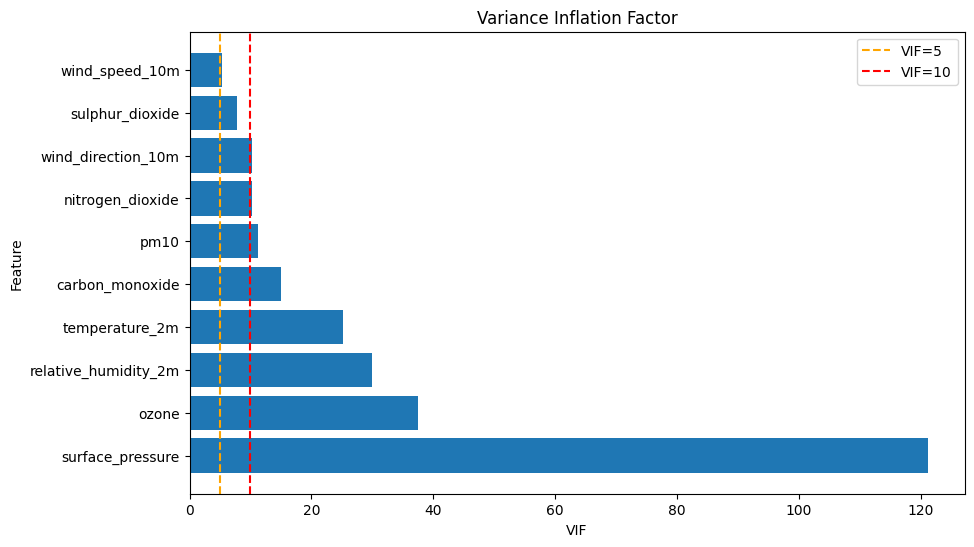

In [5]:
plt.figure(figsize=(10,6))

plt.barh(
    vif_data["Feature"],
    vif_data["VIF"]
)

plt.xlabel("VIF")
plt.ylabel("Feature")
plt.title("Variance Inflation Factor")

plt.axvline(
    x=5,
    color='orange',
    linestyle='--',
    label='VIF=5'
)

plt.axvline(
    x=10,
    color='red',
    linestyle='--',
    label='VIF=10'
)

plt.legend()
plt.show()

This shows that most of the predictor variables for pm2.5 are all highly correlated with eachother.
The predictor variables with moderatly high collinearlity are wind speed, sulphur dioxide, wind direction and nitrogen dioxide.
While the rest i.e. surface pressure, ozone, relative humidity, tempreature, carbon monoxide and pm10 all have severe multicollinerality

### 25. Temporal Feature Validation

Checking that temporal variables used are valid, consistent, and non-leaky with respect to the timeline of the data.

In [31]:
df = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

df['time'] = pd.to_datetime(
    df['time'],
    # errors='coerce',
    # dayfirst=False
)

df = df.dropna(subset=['time'])

df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.day_name()
df['month'] = df['time'].dt.month_name()
df['month_num'] = df['time'].dt.month


In [32]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['time'].dt.month.apply(get_season)


Hour Distribution:
hour
0     731
1     731
2     731
3     731
4     731
5     731
6     731
7     731
8     731
9     731
10    731
11    731
12    731
13    731
14    731
15    731
16    731
17    731
18    731
19    731
20    731
21    731
22    731
23    731
Name: count, dtype: int64


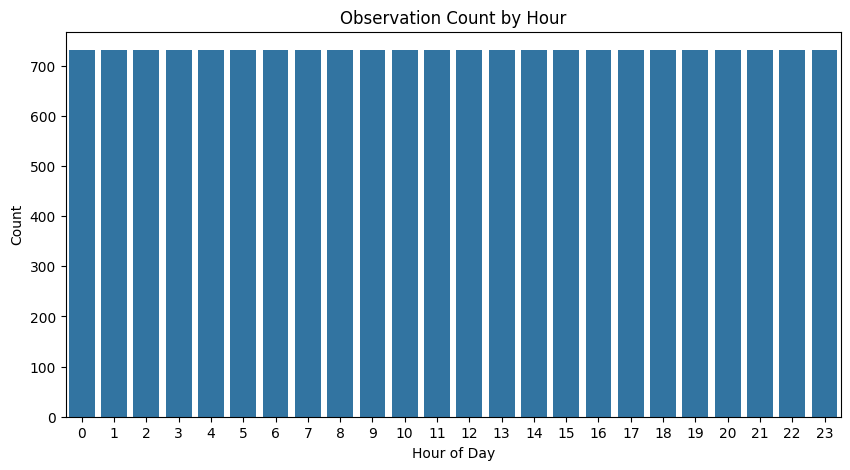

In [33]:
print("\nHour Distribution:")
print(df['hour'].value_counts().sort_index())

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='hour')
plt.title('Observation Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()



Day Distribution:
day_of_week
Sunday       2520
Monday       2520
Tuesday      2520
Wednesday    2496
Thursday     2496
Friday       2496
Saturday     2496
Name: count, dtype: int64


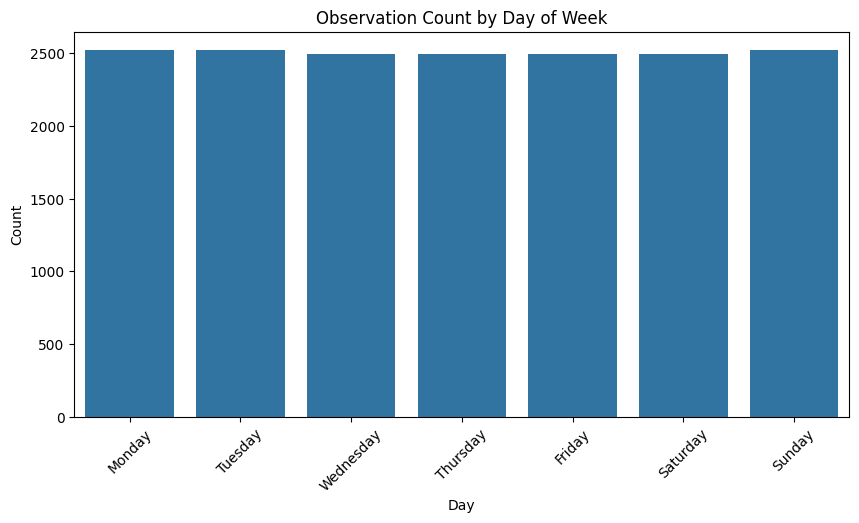

In [35]:
day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

print("\nDay Distribution:")
print(df['day_of_week'].value_counts())

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='day_of_week', order=day_order)
plt.title('Observation Count by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


Month Distribution:
month
January      1488
March        1488
May          1488
July         1488
August       1488
October      1488
December     1488
April        1440
June         1440
September    1440
November     1440
February     1368
Name: count, dtype: int64


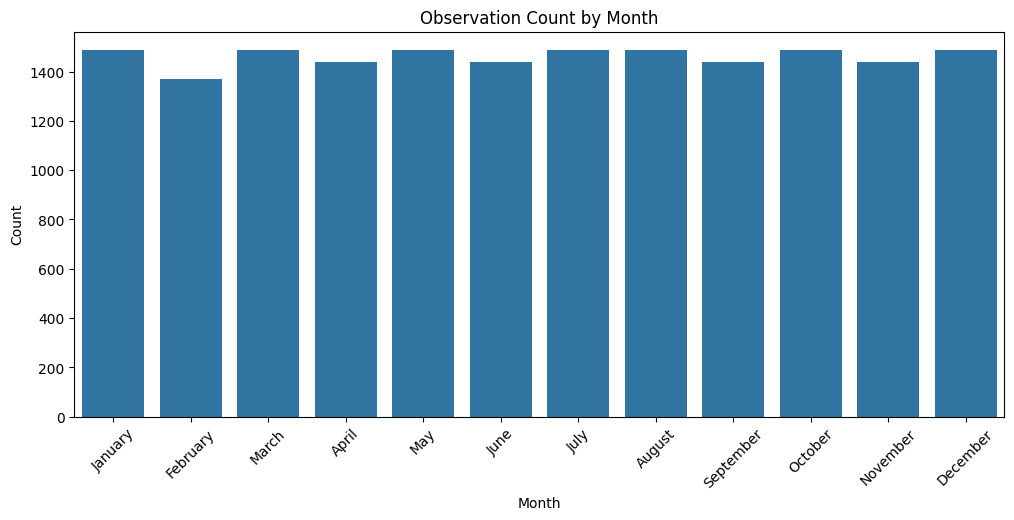

In [36]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

print("\nMonth Distribution:")
print(df['month'].value_counts())

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='month', order=month_order)
plt.title('Observation Count by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()



Season Distribution:
season
Spring    4416
Summer    4416
Autumn    4368
Winter    4344
Name: count, dtype: int64


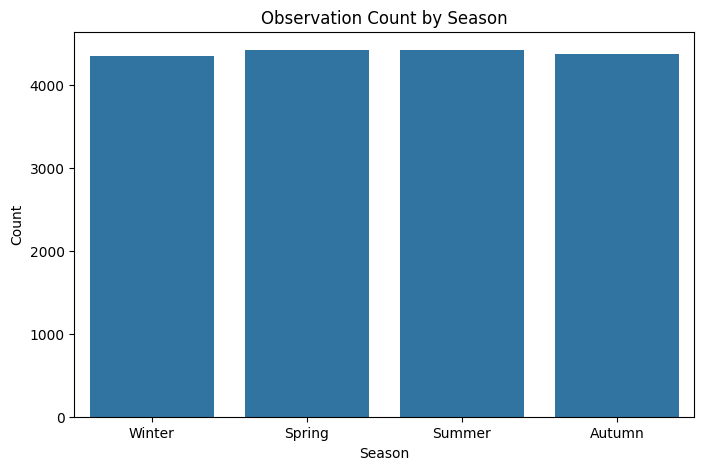

In [37]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

print("\nSeason Distribution:")
print(df['season'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='season', order=season_order)
plt.title('Observation Count by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()


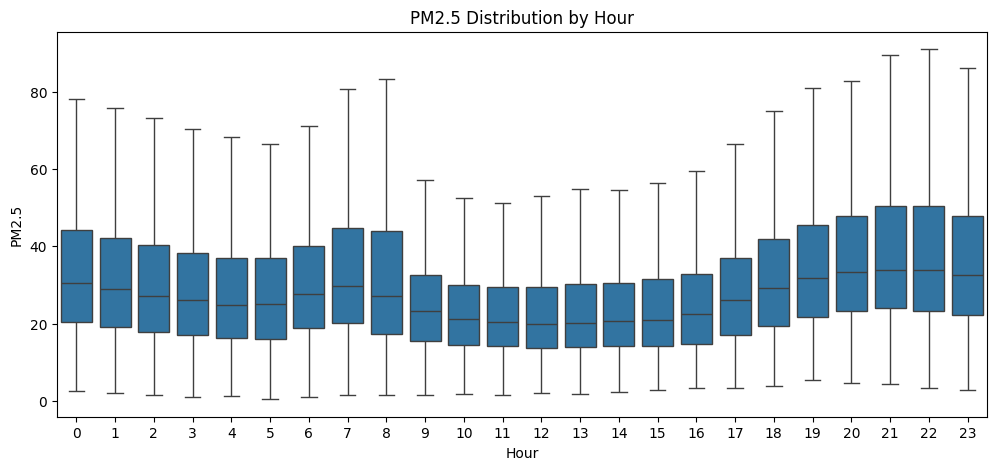

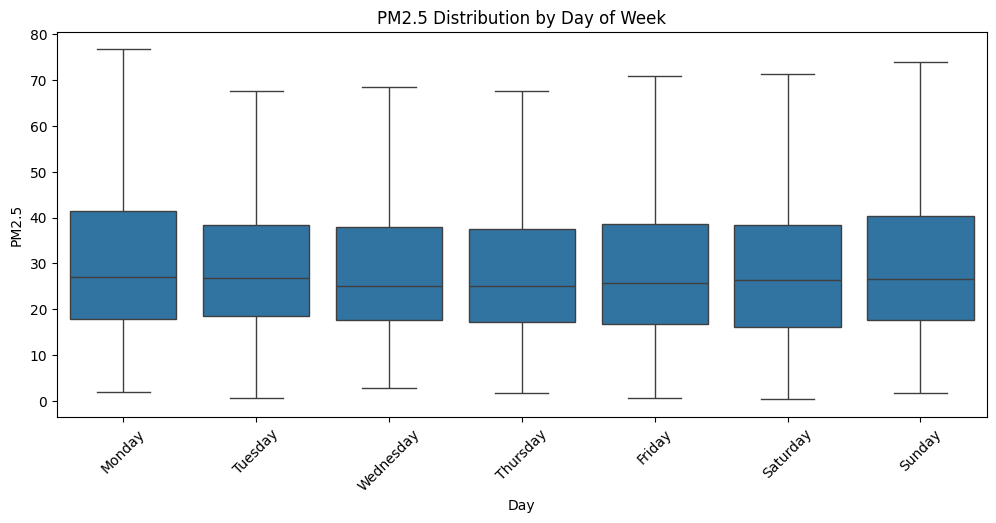

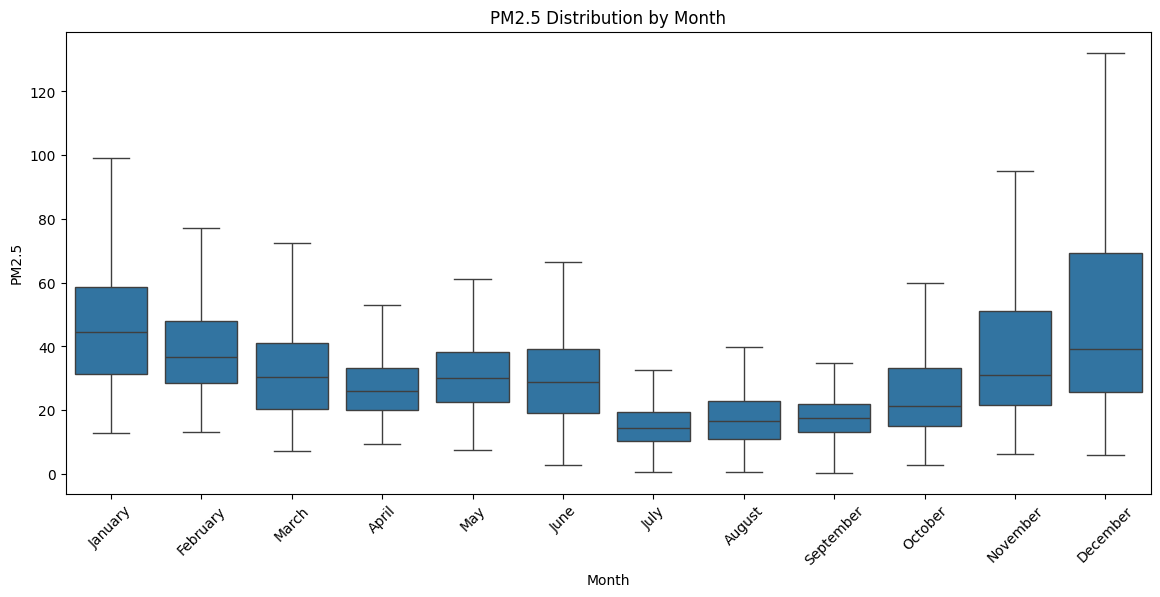

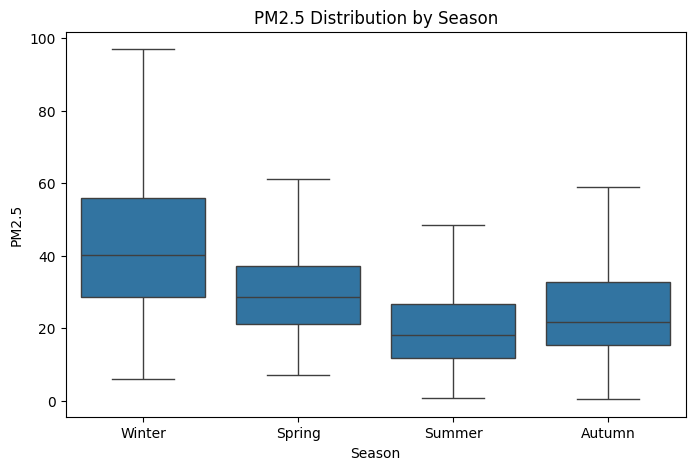

In [40]:
# Hour vs PM2.5
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='hour', y='pm2_5', showfliers=False)
plt.title('PM2.5 Distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('PM2.5')
plt.show()

# Day vs PM2.5
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='day_of_week', y='pm2_5', order=day_order, showfliers=False)
plt.title('PM2.5 Distribution by Day of Week')
plt.xlabel('Day')
plt.ylabel('PM2.5')
plt.xticks(rotation=45)
plt.show()

# Month vs PM2.5
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='month', y='pm2_5', order=month_order, showfliers=False)
plt.title('PM2.5 Distribution by Month')
plt.xlabel('Month')
plt.ylabel('PM2.5')
plt.xticks(rotation=45)
plt.show()

# Season vs PM2.5
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='season', y='pm2_5', order=season_order, showfliers=False)
plt.title('PM2.5 Distribution by Season')
plt.xlabel('Season')
plt.ylabel('PM2.5')
plt.show()

### 26. Cyclical Encoding Validation

Cyclical encoding is a technique for representing periodic features (hour of day, day of week, etc.) so a model understands that the values wrap around. Eg: 23:00 and 00:00 are close 1hr apart, even though as raw numbers they're 23 apart.

In [43]:

df = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

1. Wrap Around / Boundary Check

In [47]:
print("Hour Encoding Boundary Check")
for h in [23, 0, 1]:
    print(
        f"Hour={h:2d} -> "
        f"sin={np.sin(2*np.pi*h/24):.4f}, "
        f"cos={np.cos(2*np.pi*h/24):.4f}"
    )

print("\nMonth Encoding Boundary Check")
for m in [12, 1, 2]:
    print(
        f"Month={m:2d} -> "
        f"sin={np.sin(2*np.pi*m/12):.4f}, "
        f"cos={np.cos(2*np.pi*m/12):.4f}"
    )


Hour Encoding Boundary Check
Hour=23 -> sin=-0.2588, cos=0.9659
Hour= 0 -> sin=0.0000, cos=1.0000
Hour= 1 -> sin=0.2588, cos=0.9659

Month Encoding Boundary Check
Month=12 -> sin=-0.0000, cos=1.0000
Month= 1 -> sin=0.5000, cos=0.8660
Month= 2 -> sin=0.8660, cos=0.5000


The hour wrap around is valid as the distance between hour 0-1 and hour 23-0 is consistent.

The month wrap around is also valid as the distances between month 12-1 and month 1-2 is consistent.

2. Unit Circle Check:

Verify points lie on unit circle i.e. sin² + cos² ≈ 1.

In [49]:
df['hour_circle'] = (
    df['hour_sin']**2 + df['hour_cos']**2
)

df['month_circle'] = (
    df['month_sin']**2 + df['month_cos']**2
)

print("\nUnit Circle Validation")
print(
    "Hour:",
    df['hour_circle'].min(),
    df['hour_circle'].max()
)

print(
    "Month:",
    df['month_circle'].min(),
    df['month_circle'].max()
)



Unit Circle Validation
Hour: 0.9999999999999999 1.0
Month: 0.9999999999999999 1.0


The sin² + cos² of all data across both hour and month is min 0.99999 due to floating-point rounding error.
Therefore we can say all the points lie within unit circle.

3. Distance Comparison

In [51]:
def circular_distance(h1, h2):
    x1, y1 = np.cos(2*np.pi*h1/24), np.sin(2*np.pi*h1/24)
    x2, y2 = np.cos(2*np.pi*h2/24), np.sin(2*np.pi*h2/24)

    return np.sqrt((x1-x2)**2 + (y1-y2)**2)

print("\nDistance Validation")
print("Distance(23,0) =", circular_distance(23,0))
print("Distance(12,13) =", circular_distance(0,1))
print("Distance(0,12) =", circular_distance(0,12))


Distance Validation
Distance(23,0) = 0.261052384440104
Distance(12,13) = 0.26105238444010315
Distance(0,12) = 2.0


Our cyclical Encoding is Valid.
The distance between 23-0 and 0-1 is equal.
Similarly, the distance between two opposite ends of encoding 12-0 is 2 units. (diameter of unit circle=2)

4. Visualization of Cyclical Encoding

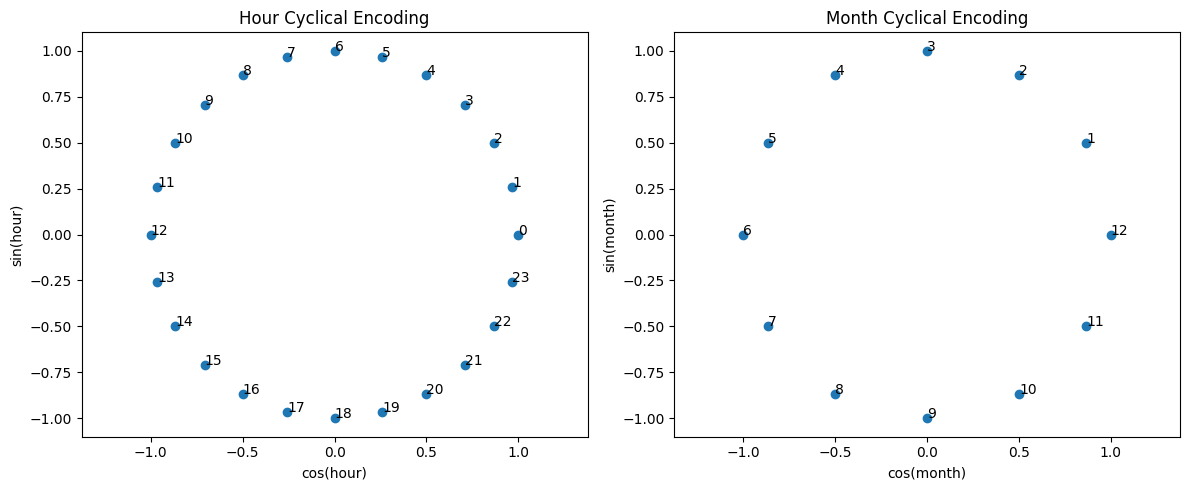

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Hour cycle
hours = np.arange(24)
hour_sin = np.sin(2*np.pi*hours/24)
hour_cos = np.cos(2*np.pi*hours/24)

ax[0].scatter(hour_cos, hour_sin)
for i in hours:
    ax[0].annotate(i, (hour_cos[i], hour_sin[i]))

ax[0].set_title("Hour Cyclical Encoding")
ax[0].set_xlabel("cos(hour)")
ax[0].set_ylabel("sin(hour)")
ax[0].axis('equal')

# Month cycle
months = np.arange(1, 13)
month_sin = np.sin(2*np.pi*months/12)
month_cos = np.cos(2*np.pi*months/12)

ax[1].scatter(month_cos, month_sin)

for i, m in enumerate(months):
    ax[1].annotate(m, (month_cos[i], month_sin[i]))

ax[1].set_title("Month Cyclical Encoding")
ax[1].set_xlabel("cos(month)")
ax[1].set_ylabel("sin(month)")
ax[1].axis('equal')

plt.tight_layout()
plt.show()


5. Correlation between encoded features and pm2.5

month_cos    0.387189
month_sin    0.276815
hour_cos     0.250385
month       -0.066984
hour         0.055666
hour_sin    -0.031578
Name: pm2_5, dtype: float64


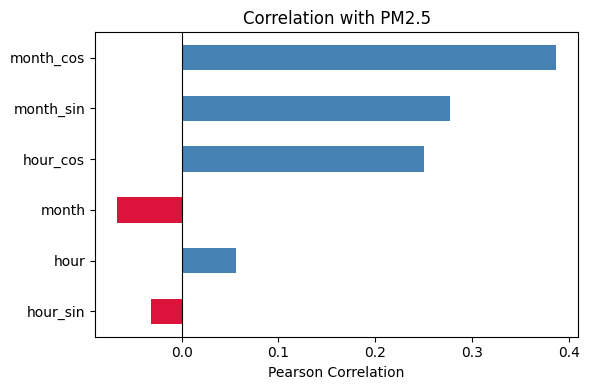

In [58]:
corr_cols = [
    'pm2_5',
    'hour',
    'hour_sin',
    'hour_cos',
    'month',
    'month_sin',
    'month_cos'
]

corr_with_pm25 = (
    df[corr_cols].corr()['pm2_5']
    .drop('pm2_5')
    .sort_values(key=abs, ascending=False)
)

print(corr_with_pm25)

plt.figure(figsize=(6,4))
colors = ['crimson' if v < 0 else 'steelblue' for v in corr_with_pm25]
corr_with_pm25.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Correlation with PM2.5")
plt.xlabel("Pearson Correlation")
plt.gca().invert_yaxis()  # strongest correlation on top
plt.tight_layout()
plt.show()


While there is a low direct month correlation as Dec (12) and Jan (1) are both high-pollution months but sit at opposite ends of the raw numeric scale, so a linear correlation can't capture that they're close seasonally.
However, cyclical encoding fixes this and therefore has a strong positive correlation with pm2.5